In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt

BATCH_SIZE = 32
IMG_SIZE = (160, 160)

data_dir = r"C:\Users\WBS\Downloads\DELPHYS2025\day04\catdog\PetImages"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)
class_names = train_dataset.class_names
print(class_names)

# Truncate to 5000 images
MAX_IMAGES = 5000
steps = MAX_IMAGES // BATCH_SIZE

train_dataset = train_dataset.take(steps)
validation_dataset = validation_dataset.take(steps // 5)  # ~20% validation

Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Found 24998 files belonging to 2 classes.
Using 4999 files for validation.
['Cat', 'Dog']


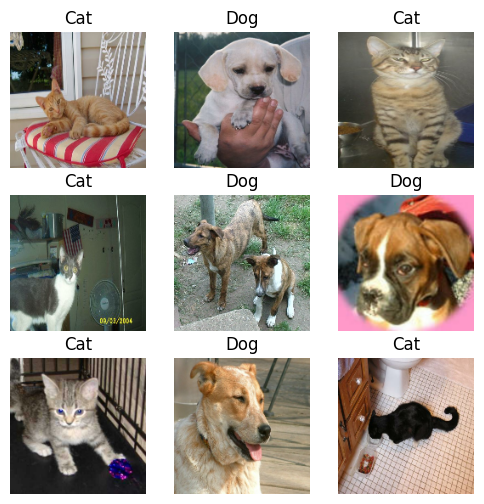

In [5]:
plt.figure(figsize=(6, 6))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [6]:
# Validation-test (80-20) split
val_batches = tf.data.experimental.cardinality(validation_dataset)
test_dataset = validation_dataset.take(val_batches // 5)
validation_dataset = validation_dataset.skip(val_batches // 5)

print('Number of validation batches: %d' %
    tf.data.experimental.cardinality(validation_dataset))
print('Number of test batches: %d' %
    tf.data.experimental.cardinality(test_dataset))

Number of validation batches: 25
Number of test batches: 6


In [7]:
# Autotune for prefetching
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

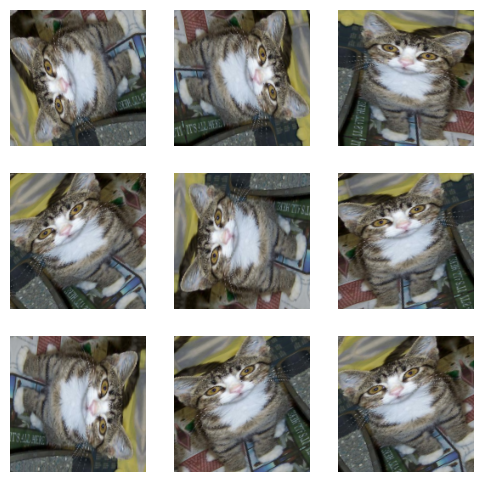

In [8]:
# Data augmentation time
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.3),
    tf.keras.layers.Rescaling(1/127.5, offset=-1) # Rescale to [-1,+1]
])

for image, _ in train_dataset.take(1):
    plt.figure(figsize=(6, 6))
    first_image = image[0]
    for i in range(9):
        plt.subplot(3, 3, i+1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow((augmented_image[0]+1) / 2)
        plt.axis('off')

In [9]:
# Get MobileNet V2 conv base
IMG_SHAPE = IMG_SIZE + (3,)
print(IMG_SHAPE)
conv_base = tf.keras.applications.MobileNetV2(
    weights="imagenet", include_top=False,
    input_shape=IMG_SHAPE)

conv_base.trainable = False
conv_base.summary()

(160, 160, 3)


Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 160, 160, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 80, 80, 32)        │             864 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 80, 80, 32)        │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 80, 80, 32)        │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 80, 80, 32)        │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 80, 80, 32)        │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 80, 80, 32)        │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 80, 80, 16)        │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 80, 80, 16)        │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 80, 80, 96)        │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 80, 80, 96)        │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 80, 80, 96)        │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 81, 81, 96)        │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 40, 40, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
# Feature extraction from conv_base
image_batch, label_batch = next(iter(train_dataset))
feature_batch = conv_base(image_batch)
print(feature_batch.shape) # (32, 5, 5, 1280)

global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape) # (32, 1280)

prediction_layer = tf.keras.layers.Dense(1)
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape) # (32, 1)

(32, 5, 5, 1280)
(32, 1280)
(32, 1)


In [11]:
# Finally, build model
inputs = tf.keras.Input(shape=(160, 160, 3))
x = data_augmentation(inputs)
x = conv_base(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_160 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │           1,281 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
# Train and plot
h1 = model.fit(train_dataset, epochs=10, validation_data=validation_dataset)

Epoch 1/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 78s 413ms/step - accuracy: 0.6338 - loss: 0.6477 - val_accuracy: 0.8525 - val_loss: 0.3274
Epoch 2/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 46s 294ms/step - accuracy: 0.8188 - loss: 0.3743 - val_accuracy: 0.9150 - val_loss: 0.2154
Epoch 3/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 46s 297ms/step - accuracy: 0.8589 - loss: 0.3047 - val_accuracy: 0.9287 - val_loss: 0.1818
Epoch 4/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 47s 296ms/step - accuracy: 0.8943 - loss: 0.2462 - val_accuracy: 0.9362 - val_loss: 0.1571
Epoch 5/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 57s 363ms/step - accuracy: 0.8945 - loss: 0.2350 - val_accuracy: 0.9538 - val_loss: 0.1325
Epoch 6/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 44s 280ms/step - accuracy: 0.9097 - loss: 0.2012 - val_accuracy: 0.9613 - val_loss: 0.1169
Epoch 7/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 51s 328ms/step - accuracy: 0.9126 - loss: 0.1934 - val_accuracy: 0.9588 - val_loss: 0.1141
Epoch 8/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 48s 301ms/step - accuracy: 0.9152 - loss: 0

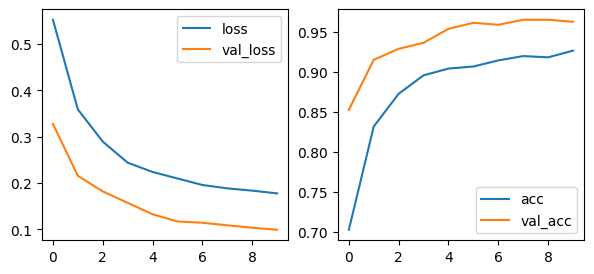

In [16]:
plt.figure(figsize=(7,3))

plt.subplot(121)
plt.plot(h1.epoch, h1.history["loss"])
plt.plot(h1.epoch, h1.history["val_loss"])
plt.legend(["loss","val_loss"])

plt.subplot(122)
plt.plot(h1.epoch, h1.history["accuracy"])
plt.plot(h1.epoch, h1.history["val_accuracy"])
plt.legend(["acc","val_acc"])

plt.show()

In [17]:
# Perhaps unfreeze after 100 layers? ('Fine tuning')
print(len(conv_base.layers)) # 154

conv_base.trainable = True
for layer in conv_base.layers[:100]:
    layer.trainable = False

# Compile again with smaller learning rate
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.RMSprop(learning_rate=1e-5),
    metrics=['accuracy'])
h2 = model.fit(train_dataset, epochs=20,
               initial_epoch=10, validation_data=validation_dataset)

154
Epoch 11/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 90s 410ms/step - accuracy: 0.8625 - loss: 0.3735 - val_accuracy: 0.9762 - val_loss: 0.0788
Epoch 12/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 67s 433ms/step - accuracy: 0.9152 - loss: 0.2033 - val_accuracy: 0.9737 - val_loss: 0.0680
Epoch 13/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 64s 407ms/step - accuracy: 0.9276 - loss: 0.1747 - val_accuracy: 0.9775 - val_loss: 0.0643
Epoch 14/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 77s 489ms/step - accuracy: 0.9345 - loss: 0.1548 - val_accuracy: 0.9762 - val_loss: 0.0507
Epoch 15/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 78s 502ms/step - accuracy: 0.9363 - loss: 0.1432 - val_accuracy: 0.9837 - val_loss: 0.0477
Epoch 16/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 83s 536ms/step - accuracy: 0.9416 - loss: 0.1408 - val_accuracy: 0.9787 - val_loss: 0.0565
Epoch 17/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 59s 381ms/step - accuracy: 0.9498 - loss: 0.1270 - val_accuracy: 0.9837 - val_loss: 0.0428
Epoch 18/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 55s 351ms/step - accuracy: 0.94

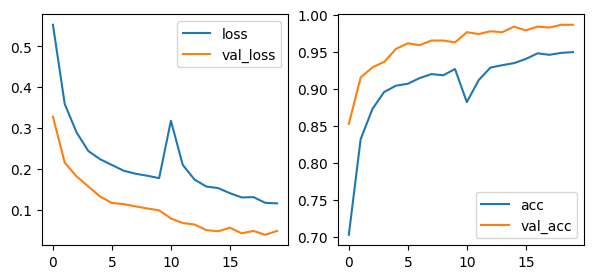

In [19]:
# Combine results and plot!
import numpy as np
epoch = np.concatenate([h1.epoch, h2.epoch])
loss = np.concatenate([h1.history["loss"], h2.history["loss"]])
val_loss = np.concatenate([h1.history["val_loss"], h2.history["val_loss"]])
acc = np.concatenate([h1.history["accuracy"], h2.history["accuracy"]])
val_acc = np.concatenate([h1.history["val_accuracy"], h2.history["val_accuracy"]])

plt.figure(figsize=(7,3))

plt.subplot(121)
plt.plot(epoch, loss)
plt.plot(epoch, val_loss)
plt.legend(["loss","val_loss"])

plt.subplot(122);
plt.plot(epoch, acc)
plt.plot(epoch, val_acc)
plt.legend(["acc","val_acc"])

plt.show()

In [20]:
test_loss, test_acc = model.evaluate(test_dataset)
print('Test accuracy :', test_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 1.0000 - loss: 0.0124
Test accuracy : 1.0


Predictions:
 [1 1 1 1 1 1 0 1 1 0 1 0 1 0 1 0 1 0 1 1 1 1 0 0 1 0 0 0 1 1 1 1]
Labels:
 [1 1 1 1 1 1 0 1 1 0 1 0 1 0 1 0 1 0 1 1 1 1 0 0 0 0 0 0 1 1 1 1]


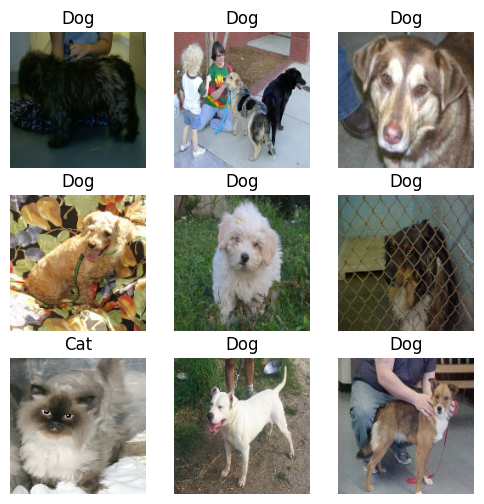

In [22]:
# Retrieve a batch of images from the test set
image_batch, label_batch = test_dataset.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch).flatten()
# Apply a sigmoid since our model returns logits
predictions = tf.nn.sigmoid(predictions)
predictions = tf.where(predictions < 0.5, 0, 1)
print('Predictions:\n', predictions.numpy())
print('Labels:\n', label_batch)


plt.figure(figsize=(6, 6))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(image_batch[i].astype("uint8"))
    plt.title(class_names[predictions[i]])
    plt.axis("off")

In [36]:
# Compare with scratch model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Input, Flatten, RandomFlip, RandomRotation, Rescaling, Dropout

model2 = Sequential()
model2.add(Input(shape=(160, 160, 3)))
# Augmentation layer
model2.add(RandomFlip('horizontal'))
model2.add(RandomRotation(0.3))
model2.add(Rescaling(1/255)) # Rescale to [0,1]
# Convolutional layer
model2.add(Conv2D(64, kernel_size=(2, 2), activation="relu"))
model2.add(MaxPooling2D(pool_size=(2, 2)))
model2.add(Conv2D(64, kernel_size=(2, 2), activation="relu"))
model2.add(MaxPooling2D(pool_size=(2, 2)))
model2.add(Conv2D(64, kernel_size=(2, 2), activation="relu"))
model2.add(MaxPooling2D(pool_size=(2, 2)))
# Prediction layer
model2.add(Dropout(0.2))
model2.add(Flatten())
model2.add(Dense(1, activation="sigmoid"))

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy'])
model2.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_flip_9 (RandomFlip)           │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation_9 (RandomRotation)   │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_9 (Rescaling)              │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_22 (Conv2D)                   │ (None, 159, 159, 64)        │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_22 (MaxPooling2D)      │ (None, 79, 79, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_23 (Conv2D)                   │ (None, 78, 78, 64)          │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_23 (MaxPooling2D)      │ (None, 39, 39, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_24 (Conv2D)                   │ (None, 38, 38, 64)          │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_24 (MaxPooling2D)      │ (None, 19, 19, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 19, 19, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 23104)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │          23,105 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 56,833 (222.00 KB)

 Trainable params: 56,833 (222.00 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
h3 = model2.fit(train_dataset, epochs=20,
               validation_data=validation_dataset)

Epoch 1/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 68s 402ms/step - accuracy: 0.5101 - loss: 0.6932 - val_accuracy: 0.5650 - val_loss: 0.6875
Epoch 2/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 92s 587ms/step - accuracy: 0.5601 - loss: 0.6843 - val_accuracy: 0.6125 - val_loss: 0.6616
Epoch 3/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 134s 860ms/step - accuracy: 0.6010 - loss: 0.6627 - val_accuracy: 0.6350 - val_loss: 0.6291
Epoch 4/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 154s 923ms/step - accuracy: 0.6452 - loss: 0.6355 - val_accuracy: 0.6612 - val_loss: 0.6200
Epoch 5/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 150s 585ms/step - accuracy: 0.6565 - loss: 0.6192 - val_accuracy: 0.6988 - val_loss: 0.5915
Epoch 6/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 124s 793ms/step - accuracy: 0.6710 - loss: 0.6113 - val_accuracy: 0.6950 - val_loss: 0.5971
Epoch 7/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 54s 346ms/step - accuracy: 0.6847 - loss: 0.6022 - val_accuracy: 0.6737 - val_loss: 0.5912
Epoch 8/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.6843 - loss:

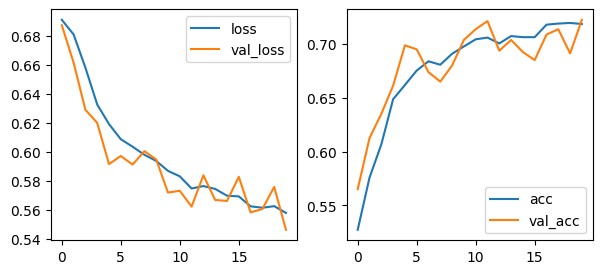

In [38]:
plt.figure(figsize=(7,3))

plt.subplot(121)
plt.plot(h3.epoch, h3.history["loss"])
plt.plot(h3.epoch, h3.history["val_loss"])
plt.legend(["loss","val_loss"])

plt.subplot(122)
plt.plot(h3.epoch, h3.history["accuracy"])
plt.plot(h3.epoch, h3.history["val_accuracy"])
plt.legend(["acc","val_acc"])

plt.show()

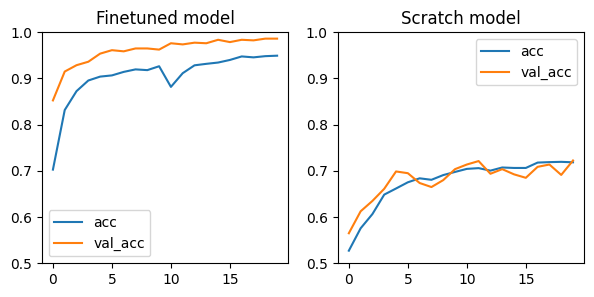

In [41]:
# Compare!
plt.figure(figsize=(7,3))

plt.subplot(121)
plt.plot(epoch, acc)
plt.plot(epoch, val_acc)
plt.title('Finetuned model')
plt.legend(["acc","val_acc"])
plt.ylim(0.5,1)

plt.subplot(122)
plt.plot(h3.epoch, h3.history["accuracy"])
plt.plot(h3.epoch, h3.history["val_accuracy"])
plt.title('Scratch model')
plt.legend(["acc","val_acc"])
plt.ylim(0.5,1)

plt.show()